# Consumption: `maf_per_km` for the upcoming segment (ICE only)

## Setup and loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

DATA = Path("./outputs/ved_enriched.parquet")
df = pd.read_parquet(DATA)
print(f"Total shape: {df.shape}")

df = df[df['EngineType'] == 'ICE'].reset_index(drop=True)
print(f"ICE-only shape: {df.shape}  ({df['VehId'].nunique()} vehicles)")

Shape totale: (17922869, 21)
Shape solo-ICE: (10401317, 21)  (197 veicoli)


## 2. Parameters and helpers for segmentation

`SEG_LEN` (meters per segment) governs the granularity. **Why 250 m and not less?** Below the
SRTM resolution (~30 m) the elevation change is noise; with irregular sampling a segment that is too short
has few points and an unstable `maf_per_km`; and the smaller it gets, the more we fall back to the
*instantaneous* prediction. 250 m is above the noise but still fine enough for anticipation. We verify this
empirically (sensitivity to `SEG_LEN`).

In [2]:
SEG_LEN = 250
MIN_SEG_FRAC = 0.5
MIN_POINTS = 4
DT_CLIP_S = 2.0

df = df.sort_values(['VehId', 'Trip', 'Timestampms']).reset_index(drop=True)
df['dist_m'] = df['dist_m'].fillna(0.0)
df['dt_ms']  = df['dt_ms'].fillna(0.0)
df['dt_s_clip'] = (df['dt_ms'] / 1000.0).clip(lower=0, upper=DT_CLIP_S)
df['air_g'] = df['MAF_g_per_sec'] * df['dt_s_clip']
elev_diff = df.groupby(['VehId', 'Trip'])['elevation_m'].diff().fillna(0.0)
df['climb_row']   = elev_diff.clip(lower=0)
df['descent_row'] = (-elev_diff).clip(lower=0)
df['accel_abs'] = df['accel_kmh_s'].abs()
df['is_stop']   = (df['Vehicle_Speed_km_per_h'] < 2).astype(float)
df['hour']  = df['Datetime'].dt.hour
df['month'] = df['Datetime'].dt.month

## 3. Building the segments

Within each trip we accumulate distance and cut a segment every `SEG_LEN` meters. We aggregate the
rows into the features known in advance (geometry + speed profile) and into the target `maf_per_km`.

In [3]:
SEG_KEYS = ['VehId', 'Trip', 'seg_in_trip']

def build_segments(d, seg_len):
    d = d.copy()
    d['cum_dist'] = d.groupby(['VehId', 'Trip'])['dist_m'].cumsum()
    d['seg_in_trip'] = (d['cum_dist'] // seg_len).astype(int)
    seg = d.groupby(SEG_KEYS, sort=True).agg(
        n_points=('MAF_g_per_sec', 'size'),
        seg_distance_m=('dist_m', 'sum'),
        seg_time_s=('dt_s_clip', 'sum'),
        air_total_g=('air_g', 'sum'),
        elev_start=('elevation_m', 'first'),
        elev_end=('elevation_m', 'last'),
        climb_m=('climb_row', 'sum'),
        descent_m=('descent_row', 'sum'),
        slope_mean=('slope', 'mean'),
        slope_max_abs=('slope', lambda s: s.abs().max()),
        speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
        speed_max=('Vehicle_Speed_km_per_h', 'max'),
        speed_min=('Vehicle_Speed_km_per_h', 'min'),
        speed_std=('Vehicle_Speed_km_per_h', 'std'),
        entry_speed=('Vehicle_Speed_km_per_h', 'first'),
        accel_abs_mean=('accel_abs', 'mean'),
        stop_fraction=('is_stop', 'mean'),
        OAT_DegC=('OAT_DegC', 'mean'),
        Generalized_Weight=('Generalized_Weight', 'first'),
        hour=('hour', 'first'),
        month=('month', 'first'),
        Datetime=('Datetime', 'first'),
    ).reset_index()
    seg['dz_net'] = seg['elev_end'] - seg['elev_start']
    seg['speed_std'] = seg['speed_std'].fillna(0.0)
    seg['maf_per_km'] = seg['air_total_g'] / (seg['seg_distance_m'] / 1000.0)
    seg = seg[(seg['seg_distance_m'] >= MIN_SEG_FRAC * seg_len) &
              (seg['n_points'] >= MIN_POINTS) &
              np.isfinite(seg['maf_per_km'])].reset_index(drop=True)
    return seg

seg = build_segments(df, SEG_LEN)
print(f"Segments (SEG_LEN={SEG_LEN} m): {len(seg):,} | trips: {seg.groupby(['VehId','Trip']).ngroups:,}")
print(seg[['seg_distance_m','speed_mean','dz_net','climb_m','maf_per_km']].describe().round(2))

Segmenti (SEG_LEN=250 m): 299,655 | trip: 14,676
       seg_distance_m  speed_mean     dz_net    climb_m  maf_per_km
count       299655.00   299655.00  299655.00  299655.00   299655.00
mean           248.76       56.58      -0.09      16.11     1064.77
std             62.30       27.48      18.83      17.05      855.26
min            125.01        0.00     -94.00       0.00        0.00
25%            230.64       38.18      -8.00       2.00      563.09
50%            248.39       55.58       0.00      10.00      865.84
75%            265.79       68.53       8.00      26.00     1347.22
max           9203.59      169.91      81.00     211.00    84575.82


## Coupling features

In [4]:
def add_coupling(seg):
    seg = seg.sort_values(['VehId', 'Trip', 'seg_in_trip']).reset_index(drop=True)
    g = seg.groupby(['VehId', 'Trip'])
    seg['next_dz_net']        = g['dz_net'].shift(-1)
    seg['next_slope_mean']    = g['slope_mean'].shift(-1)
    seg['next_stop_fraction'] = g['stop_fraction'].shift(-1)
    for c in ['next_dz_net', 'next_slope_mean', 'next_stop_fraction']:
        seg[c] = seg[c].fillna(0.0)
    return seg

seg = add_coupling(seg)
print("Coupling added.")

Accoppiamento aggiunto.


## Target and features

Target `maf_per_km`. Features: geometry/road + speed profile + coupling + context.
`EngineType` is not present (constant = ICE). RPM/Load excluded.
no PCA

In [5]:
TARGET = 'maf_per_km'
FEATURES_NUM = [
    'seg_distance_m', 'dz_net', 'climb_m', 'descent_m', 'slope_mean', 'slope_max_abs',
    'speed_mean', 'speed_max', 'speed_min', 'speed_std', 'accel_abs_mean', 'stop_fraction',
    'entry_speed', 'next_dz_net', 'next_slope_mean', 'next_stop_fraction',
    'Generalized_Weight', 'OAT_DegC', 'hour', 'month',
]
GROUP_COL = 'VehId'
seg_model = seg.dropna(subset=FEATURES_NUM + [TARGET]).reset_index(drop=True)
print(f"Segments for modeling: {len(seg_model):,} | features: {len(FEATURES_NUM)}")

Segmenti per il modeling: 299,655 | feature: 20


## Temporal split by trip

80% oldest trips in train, 20% most recent in test (simulates deployment, no temporal leakage).

In [6]:
trip_start = seg_model.groupby(['VehId', 'Trip'])['Datetime'].min().sort_values()
n_train = int(len(trip_start) * 0.8)
train_trips = set(zip(trip_start.iloc[:n_train].index.get_level_values(0),
                      trip_start.iloc[:n_train].index.get_level_values(1)))
seg_model['_key'] = list(zip(seg_model['VehId'], seg_model['Trip']))
train_df = seg_model[seg_model['_key'].isin(train_trips)].drop(columns='_key').reset_index(drop=True)
test_df  = seg_model[~seg_model['_key'].isin(train_trips)].drop(columns='_key').reset_index(drop=True)
seg_model = seg_model.drop(columns='_key')

X_train, y_train = train_df[FEATURES_NUM], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES_NUM],  test_df[TARGET]
groups_train = train_df[GROUP_COL]
print(f"Train: {len(X_train):,} segments | Test: {len(X_test):,}")
print(f"Train period: {train_df['Datetime'].min()} -> {train_df['Datetime'].max()}")
print(f"Test period:  {test_df['Datetime'].min()} -> {test_df['Datetime'].max()}")

Train: 239,246 segmenti | Test: 60,409
Periodo train: 2017-11-01 00:22:18.618851 -> 2018-07-26 14:35:26.074219
Periodo test:  2018-07-26 15:50:53.320312 -> 2018-11-10 12:01:42.832031


## Report function

We define the `report` function (MAE/RMSE/MAPE/R2). **No scaler:** the model is XGBoost (tree-based),
**invariant to monotone transformations** of the features -> `StandardScaler` would not change the
predictions. The numeric features enter the model raw.

In [7]:
def report(name, y_true, y_pred, store=None):
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true > 1.0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:25s}  MAE={mae:7.2f}  RMSE={rmse:7.2f}  MAPE={mape:6.2f}%  R2={r2:6.3f}")
    row = {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}
    if store is not None: store.append(row)
    return row

results = []
print("Report function ready.")

Funzione di report pronta.


## XGBoost (default)

State of the art for tabular data: it is the natural candidate. We train it with default hyperparameters as a reference, before tuning.

In [8]:
xgb_default = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1, n_jobs=-1,
    random_state=RANDOM_STATE, tree_method='hist')
xgb_default.fit(X_train, y_train)
report("XGBoost (default)", y_test, xgb_default.predict(X_test), results)

XGBoost (default)          MAE= 248.18  RMSE= 360.88  MAPE= 32.87%  R2= 0.762


{'model': 'XGBoost (default)',
 'MAE': 248.17926330278235,
 'RMSE': np.float64(360.882525944404),
 'MAPE': 32.87221682560451,
 'R2': 0.7615546540643799}

## Tuning with Optuna (TPE) + GroupKFold by VehId

GroupKFold by VehId: the same vehicle is not in
train and validation together.

In [9]:
N_TRIALS = 30
N_SPLITS = 4

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    model = xgb.XGBRegressor(**params, n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist')
    gkf = GroupKFold(n_splits=N_SPLITS)
    maes = []
    for tr, va in gkf.split(X_train, y_train, groups=groups_train):
        model.fit(X_train.iloc[tr], y_train.iloc[tr])
        maes.append(mean_absolute_error(y_train.iloc[va], model.predict(X_train.iloc[va])))
    return np.mean(maes)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print("\nBest params:", study.best_params)
print(f"Best CV MAE: {study.best_value:.3f}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best params: {'n_estimators': 499, 'max_depth': 8, 'learning_rate': 0.09521341606711148, 'min_child_weight': 3, 'subsample': 0.8438575689199829, 'colsample_bytree': 0.9043119941054648, 'reg_alpha': 0.1798235259530552, 'reg_lambda': 1.2316527755472544}
Best CV MAE: 277.631


## Tuned XGBoost, compared

XGBoost (tuned)            MAE= 242.38  RMSE= 357.84  MAPE= 31.91%  R2= 0.766
            model        MAE       RMSE      MAPE       R2
XGBoost (default) 248.179263 360.882526 32.872217 0.761555
  XGBoost (tuned) 242.379233 357.842099 31.914434 0.765556


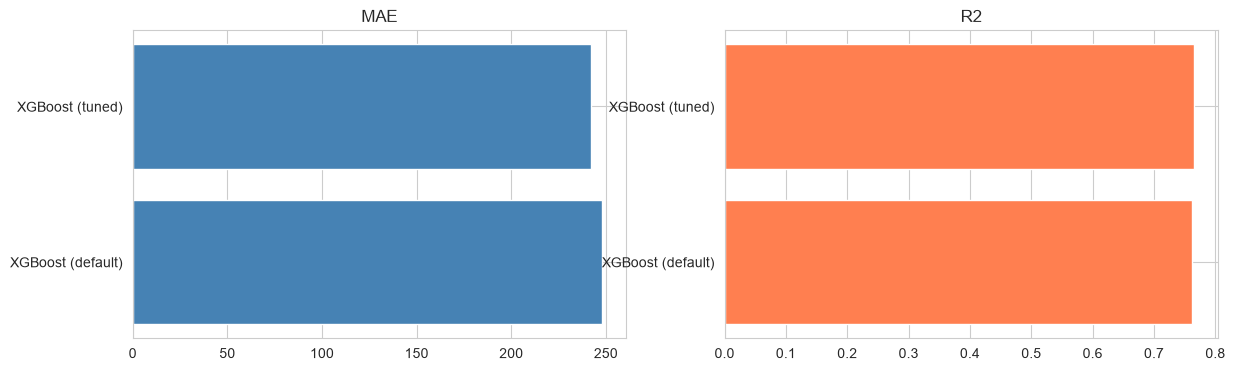

In [10]:
xgb_final = xgb.XGBRegressor(
    **study.best_params, n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist')
xgb_final.fit(X_train, y_train)
y_pred_xgb = xgb_final.predict(X_test)
report("XGBoost (tuned)", y_test, y_pred_xgb, results)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(results_df['model'], results_df['MAE'], color='steelblue'); axes[0].set_title('MAE')
axes[1].barh(results_df['model'], results_df['R2'], color='coral'); axes[1].set_title('R2')
plt.show()

## Feature importance

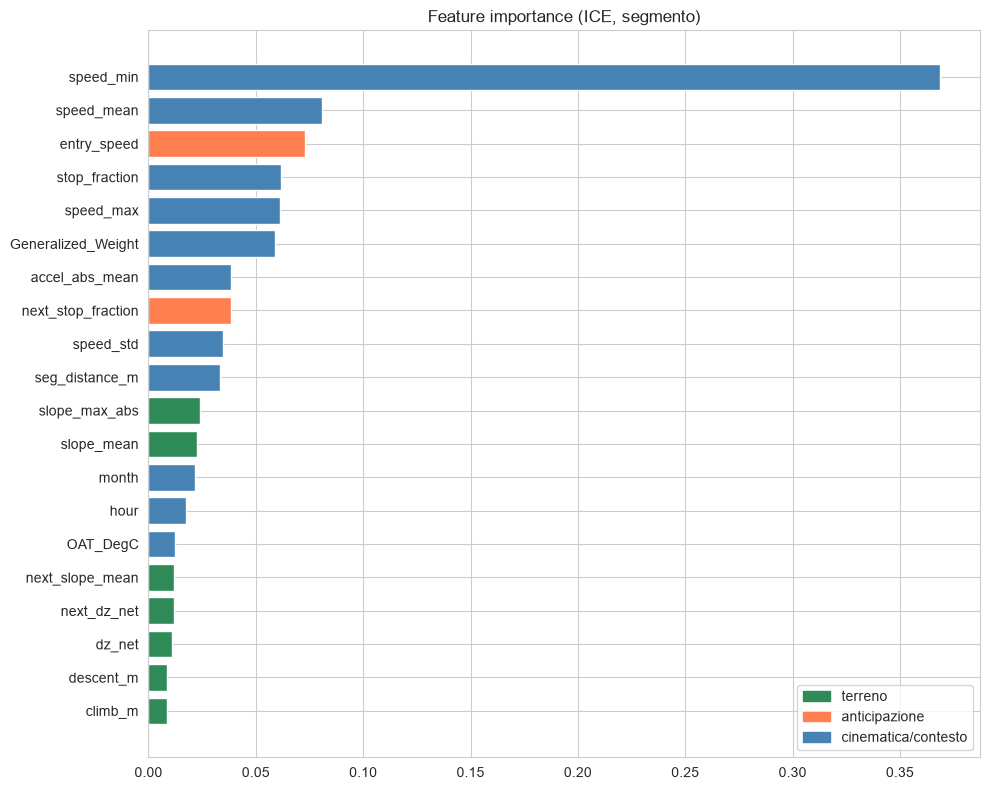

Peso TERRENO: 0.099 | ANTICIPAZIONE: 0.111
           feature  importance
         speed_min    0.368835
        speed_mean    0.080923
       entry_speed    0.072963
     stop_fraction    0.061805
         speed_max    0.061156
Generalized_Weight    0.059042
    accel_abs_mean    0.038434
next_stop_fraction    0.038269
         speed_std    0.034785
    seg_distance_m    0.033348
     slope_max_abs    0.023885
        slope_mean    0.022724


In [11]:
model = xgb_final
imp = pd.DataFrame({'feature': FEATURES_NUM, 'importance': model.feature_importances_}).sort_values('importance')
def fam(f):
    if any(k in f for k in ['slope', 'dz', 'climb', 'descent']): return 'terrain'
    if f.startswith('next_') or f.startswith('entry_'):          return 'anticipation'
    return 'kinematics/context'
cmap = {'terrain': 'seagreen', 'anticipation': 'coral', 'kinematics/context': 'steelblue'}
colors = [cmap[fam(f)] for f in imp['feature']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp['feature'], imp['importance'], color=colors)
handles = [plt.Rectangle((0,0),1,1,color=c) for c in cmap.values()]
ax.legend(handles, cmap.keys(), loc='lower right'); ax.set_title('Feature importance (ICE, segment)')
plt.tight_layout(); plt.show()
terr = imp[imp['feature'].apply(lambda f: fam(f)=='terrain')]['importance'].sum()
anti = imp[imp['feature'].apply(lambda f: fam(f)=='anticipation')]['importance'].sum()
print(f"TERRAIN weight: {terr:.3f} | ANTICIPATION: {anti:.3f}")
print(imp.sort_values('importance', ascending=False).head(12).to_string(index=False))